In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")

In [3]:
df["fast_adopt"] = df["AdoptionSpeed"] <= 1

df["is_young"] = df["Age"] <= 6
df["is_free"] = df["Fee"] == 0
df["is_healthy"] = df["Health"] == 1

df["Type"] = df["Type"] - 1

features = ["is_young", "is_free", "is_healthy", "Type", "PhotoAmt"]

X = df[features]
y = df["fast_adopt"]

X = X.fillna(0)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train-Test Split

We split the dataset into training and testing sets:

- 80% training data
- 20% testing data

This allows us to evaluate model performance on unseen data.

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Model: Logistic Regression

We use Logistic Regression as a baseline model.

It is simple, interpretable, and suitable for binary classification tasks.

In [6]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7602534178059354


In [7]:
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
0,is_young,0.417095
3,Type,0.415750
2,is_healthy,0.066139
1,is_free,-0.010065
4,PhotoAmt,-0.034651


### Insight: Feature Importance

From the logistic regression coefficients:

- **is_young** has the strongest positive impact → younger pets are much more likely to be adopted quickly  
- **Type** also has strong influence → cats/dogs show clear difference in adoption speed  
- **is_healthy** has a positive effect → healthier pets are preferred  
- **is_free** has almost no impact  
- **PhotoAmt** shows slight negative effect (unexpected)

Overall, age and type are the most important factors.

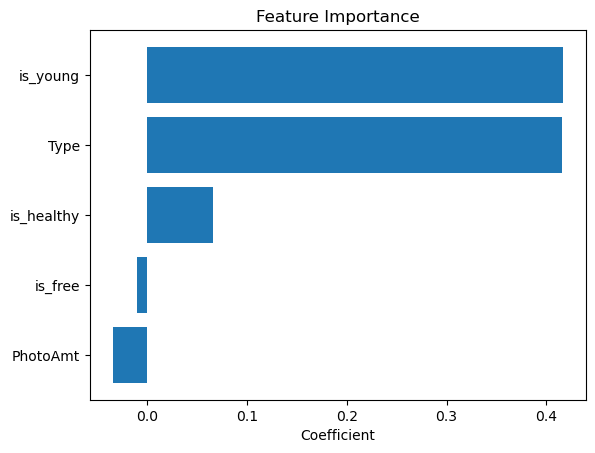

In [8]:
import matplotlib.pyplot as plt

coef_df_sorted = coef_df.sort_values(by="Coefficient")

plt.barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"])
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.show()

## Baseline Model Summary

The logistic regression model achieved an accuracy of approximately **0.76**.

Key findings:

- Age (is_young) is the most important factor
- Pet type significantly affects adoption
- Health condition has moderate influence
- Fee has little impact
- Photo count does not improve prediction

This model serves as a baseline for comparison with image-based models.